## 1. Setup and Data Preparation

In [1]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4120 sha256=3c31d2e92f06c5309c75fbb66e88124f65b695461248b7e0519444611351c4f9
  Stored in directory: /root/.cache/pip/wheels/7e/16/46/9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import lifelines

from lifelines.datasets import load_rossi

In [3]:
df = load_rossi()
df.head()

,week,arrest,fin,age,race,wexp,mar,paro,prio
0,20,1,0,27,1,0,0,1,3
1,17,1,0,18,1,0,0,1,8
2,25,1,0,19,0,1,0,1,13
3,52,0,1,23,1,1,1,1,1
4,52,0,0,19,0,1,0,1,3


In [4]:
df = df.rename(columns={
    "week": "T",
    "arrest": "E"
})

df.head()

,T,E,fin,age,race,wexp,mar,paro,prio
0,20,1,0,27,1,0,0,1,3
1,17,1,0,18,1,0,0,1,8
2,25,1,0,19,0,1,0,1,13
3,52,0,1,23,1,1,1,1,1
4,52,0,0,19,0,1,0,1,3


### Dataset variables

- **T** = number of weeks until rearrest or until the end of the follow-up period.
- **E = 1** = the individual was rearrested during the follow-up period.
- **E = 0** = no rearrest was observed by the end of the follow-up period, so the observation is censored.

### AI Question

**In the Rossi dataset, what does censoring mean? Why should an individual with E = 0 not be treated as if the event occurred at time T?**

## 2. Visualizing Survival Times and Censoring

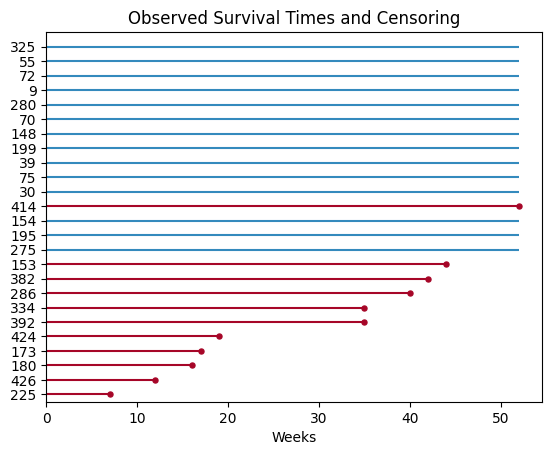

In [5]:
from lifelines.plotting import plot_lifetimes

df_sample = df.sample(25, random_state=42)

plot_lifetimes(
    df_sample["T"],
    event_observed=df_sample["E"]
)

plt.xlabel("Weeks")
plt.title("Observed Survival Times and Censoring")
plt.show()

### Interpretation

Each horizontal line represents one individual in the sample.

- **Red lines with a point at the end** represent individuals who were rearrested during the follow-up period (`E = 1`).
- **Blue lines** represent censored observations (`E = 0`), meaning that no rearrest was observed before the end of the follow-up period.
- The length of each line represents the observed follow-up time in weeks.

## 3. Exploring the Distribution of Follow-up Times

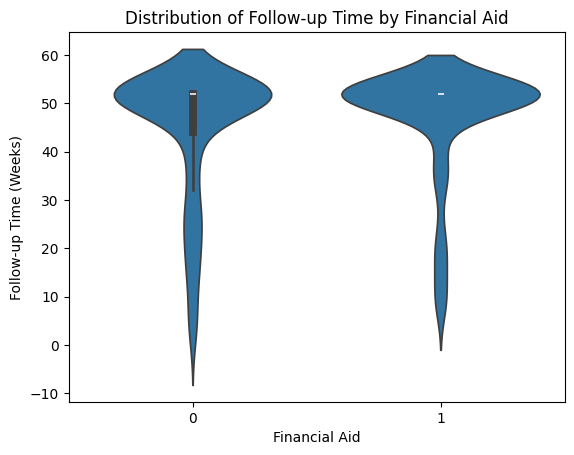

In [6]:
sns.violinplot(x="fin", y="T", data=df)

plt.xlabel("Financial Aid")
plt.ylabel("Follow-up Time (Weeks)")
plt.title("Distribution of Follow-up Time by Financial Aid")
plt.show()

### AI Question

**Why does the violin plot show values below zero even though follow-up time cannot be negative?**

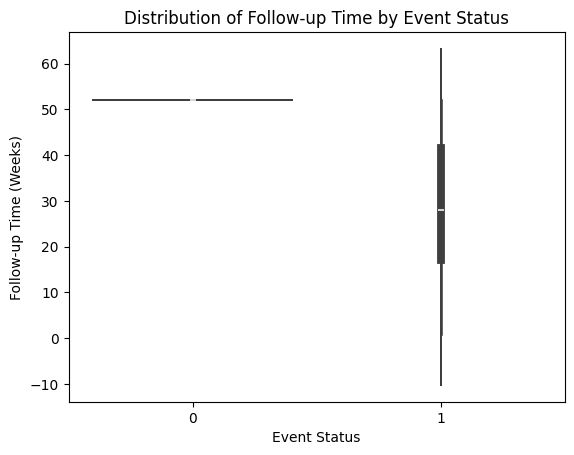

In [7]:
sns.violinplot(x="E", y="T", data=df)

plt.xlabel("Event Status")
plt.ylabel("Follow-up Time (Weeks)")
plt.title("Distribution of Follow-up Time by Event Status")
plt.show()

### Interpretation

Individuals with `E = 0` were censored at the end of the 52-week follow-up period.

For individuals with `E = 1`, the time to rearrest varies considerably across the follow-up period.

In [8]:
df.describe()

,T,E,fin,age,race,wexp,mar,paro,prio
count,432.000000,432.000000,432.00000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000
mean,45.854167,0.263889,0.50000,24.597222,0.877315,0.571759,0.122685,0.618056,2.983796
std,12.662293,0.441251,0.50058,6.113375,0.328456,0.495398,0.328456,0.486426,2.896068
min,1.000000,0.000000,0.00000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50.000000,0.000000,0.00000,20.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,52.000000,0.000000,0.50000,23.000000,1.000000,1.000000,0.000000,1.000000,2.000000
75%,52.000000,1.000000,1.00000,27.000000,1.000000,1.000000,0.000000,1.000000,4.000000
max,52.000000,1.000000,1.00000,44.000000,1.000000,1.000000,1.000000,1.000000,18.000000


## 4. Parametric Survival Modeling – Exponential Distribution

### AI Question

**Why is the exponential distribution commonly used as a starting model for the time until an event occurs?**

loc = 1.0
scale = 27.545454545454547


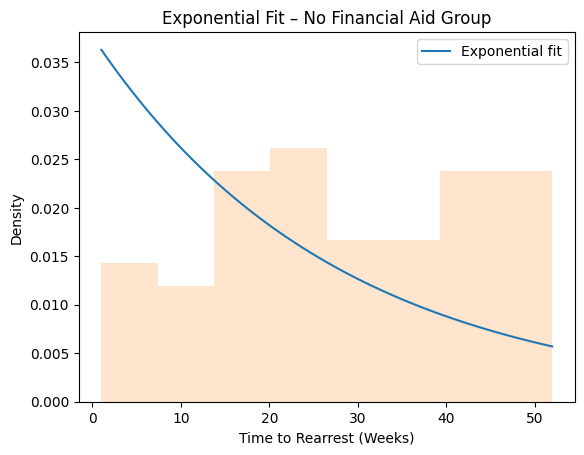

In [9]:
from scipy.stats import expon

no_aid = df[df["fin"] == 0]
observed = no_aid[no_aid["E"] == 1]

loc, scale = expon.fit(observed["T"])
RV = expon(loc, scale)

print("loc =", loc)
print("scale =", scale)

x = np.linspace(no_aid["T"].min(), no_aid["T"].max(), 100)

plt.plot(x, RV.pdf(x), label="Exponential fit")
plt.hist(
    observed["T"],
    density=True,
    bins="auto",
    histtype="stepfilled",
    alpha=0.2
)

plt.xlabel("Time to Rearrest (Weeks)")
plt.ylabel("Density")
plt.title("Exponential Fit – No Financial Aid Group")
plt.legend()
plt.show()

### Interpretation

The exponential distribution provides a simple parametric model for the observed time-to-rearrest data. However, the fitted exponential density does not closely follow the shape of the observed distribution, suggesting that a more flexible survival distribution may provide a better fit.

### AI Question

**What is a Maximum Likelihood Estimation (MLE) fit, and how is it used to estimate the parameters of an exponential survival model?**

Weibull parameters: 1.9433151148466727 0 31.898347606224352


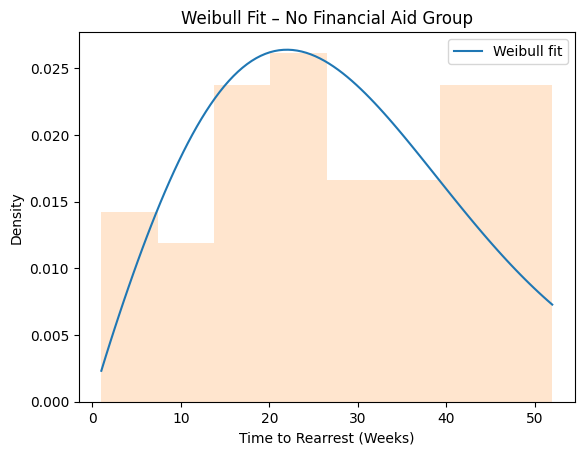

In [10]:
from scipy.stats import weibull_min

params = weibull_min.fit(observed["T"], floc=0)
RV_weibull = weibull_min(*params)

print("Weibull parameters:", *params)

x = np.linspace(no_aid["T"].min(), no_aid["T"].max(), 100)

plt.plot(x, RV_weibull.pdf(x), label="Weibull fit")
plt.hist(
    observed["T"],
    density=True,
    bins="auto",
    histtype="stepfilled",
    alpha=0.2
)

plt.xlabel("Time to Rearrest (Weeks)")
plt.ylabel("Density")
plt.title("Weibull Fit – No Financial Aid Group")
plt.legend()
plt.show()

### Comparing Exponential and Weibull Models

In [11]:
LL_exponential = np.sum(
    expon.logpdf(observed["T"], loc, scale)
)

LL_weibull = np.sum(
    weibull_min.logpdf(observed["T"], *params)
)

print("Exponential log-likelihood:", LL_exponential)
print("Weibull log-likelihood:", LL_weibull)

Exponential log-likelihood: -284.8452771589259
Weibull log-likelihood: -271.5038760743011


### Interpretation

The Weibull model has a higher log-likelihood than the exponential model, indicating a better fit to the observed time-to-rearrest data.

### AI Question

**How should right-censored observations be incorporated when fitting a Weibull survival model, and why should they not simply be excluded?**

### Weibull Model with Right-Censored Data

rho = 1.3239642552727304
lambda = 111.71051916681759


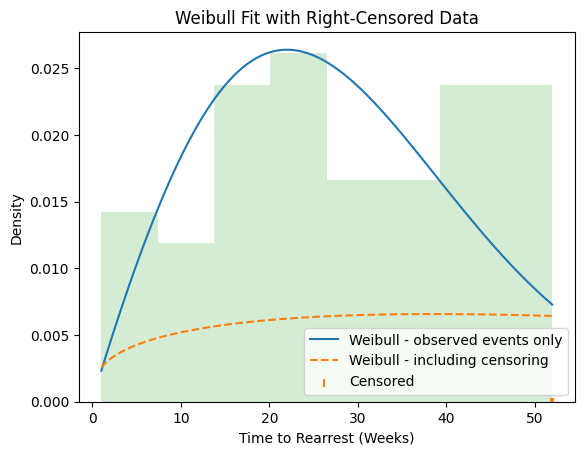

In [12]:
from lifelines import WeibullFitter

wf = WeibullFitter()

wf.fit(
    no_aid["T"],
    event_observed=no_aid["E"]
)

lambda_ = wf.lambda_
rho_ = wf.rho_

print("rho =", rho_)
print("lambda =", lambda_)

x = np.linspace(no_aid["T"].min(), no_aid["T"].max(), 100)

pdf_lifelines = (
    (rho_ / lambda_)
    * (x / lambda_)**(rho_ - 1)
    * np.exp(-(x / lambda_)**rho_)
)

plt.plot(x, RV_weibull.pdf(x), label="Weibull - observed events only")
plt.plot(x, pdf_lifelines, "--", label="Weibull - including censoring")

plt.hist(
    observed["T"],
    density=True,
    bins="auto",
    histtype="stepfilled",
    alpha=0.2
)

censored = no_aid[no_aid["E"] == 0]

plt.scatter(
    censored["T"],
    np.zeros_like(censored["T"]),
    marker="|",
    label="Censored"
)

plt.xlabel("Time to Rearrest (Weeks)")
plt.ylabel("Density")
plt.title("Weibull Fit with Right-Censored Data")
plt.legend()
plt.show()

### Interpretation

Including right-censored observations substantially changes the fitted Weibull model.

The censored observations still provide information: although the event was not observed, we know that the individual remained event-free at least until time `T`.

Therefore, excluding censored observations can lead to a biased estimate of the survival-time distribution.

## 5. Non-Parametric Survival Analysis

Instead of assuming a specific probability distribution, we can estimate the survival function directly from the observed data.

\[
S(t) = 1 - CDF(t)
\]

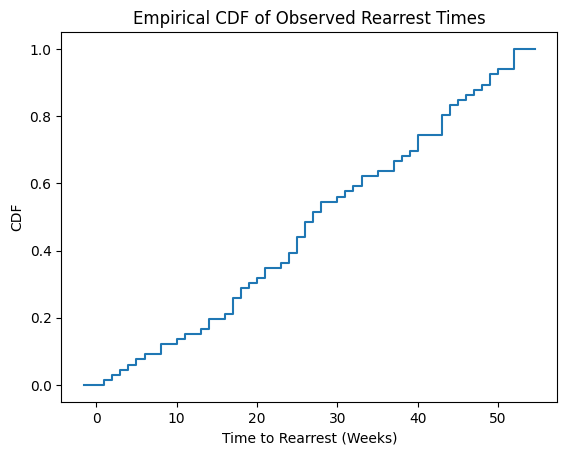

In [13]:
ecdf = stats.ecdf(observed["T"])

ecdf.cdf.plot()

plt.xlabel("Time to Rearrest (Weeks)")
plt.ylabel("CDF")
plt.title("Empirical CDF of Observed Rearrest Times")
plt.show()

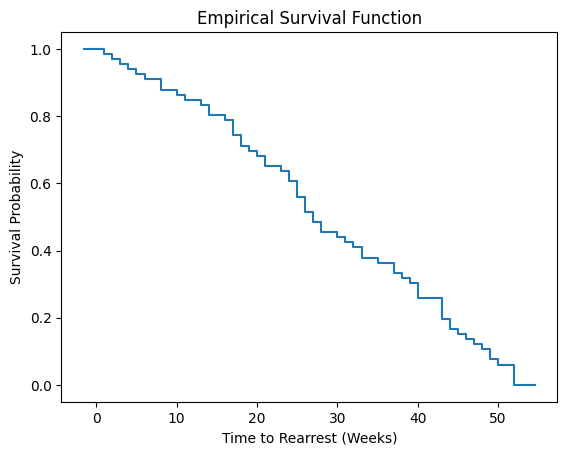

In [14]:
ecdf.sf.plot()

plt.xlabel("Time to Rearrest (Weeks)")
plt.ylabel("Survival Probability")
plt.title("Empirical Survival Function")
plt.show()

### Interpretation

The empirical survival function decreases over time, indicating that the probability of remaining without rearrest becomes lower as the follow-up period progresses.

This estimate is based only on the observed rearrest times and does not yet properly account for censored observations.

### Kaplan–Meier Estimator and Censoring

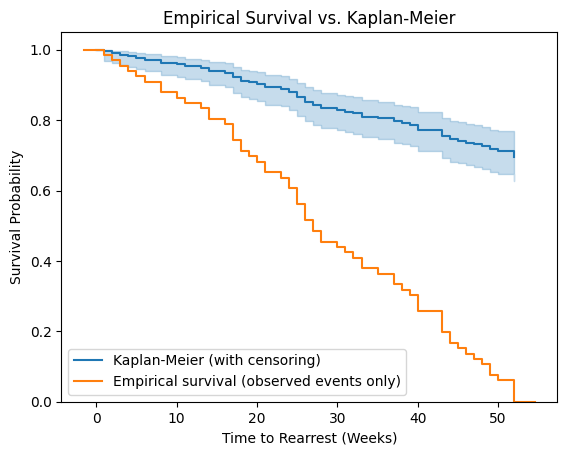

In [15]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

kmf.fit(
    no_aid["T"],
    event_observed=no_aid["E"],
    label="Kaplan-Meier (with censoring)"
)

ax = kmf.plot_survival_function()

ecdf.sf.plot(
    ax=ax,
    label="Empirical survival (observed events only)"
)

plt.xlabel("Time to Rearrest (Weeks)")
plt.ylabel("Survival Probability")
plt.title("Empirical Survival vs. Kaplan-Meier")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

### Interpretation

The empirical survival curve based only on observed rearrests decreases much faster than the Kaplan–Meier estimate.

By excluding censored individuals, the empirical approach underestimates the probability of remaining without rearrest.

The Kaplan–Meier estimator incorporates censored observations and therefore provides a more appropriate estimate of the survival function.

### AI Question

**Why does ignoring censored observations lead to an underestimated survival probability, and how does the Kaplan–Meier estimator correct this problem?**

### Nelson-Aalen Cumulative Hazard Estimate

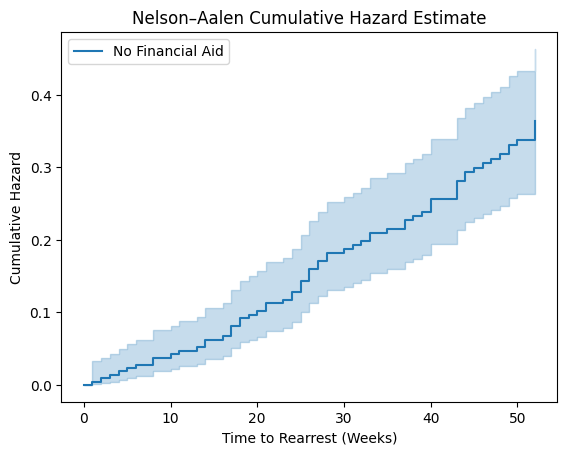

In [16]:
from lifelines import NelsonAalenFitter

naf = NelsonAalenFitter()

naf.fit(
    no_aid["T"],
    event_observed=no_aid["E"],
    label="No Financial Aid"
)

naf.plot_cumulative_hazard()

plt.xlabel("Time to Rearrest (Weeks)")
plt.ylabel("Cumulative Hazard")
plt.title("Nelson–Aalen Cumulative Hazard Estimate")
plt.show()

### Interpretation

The cumulative hazard increases over time, indicating that the accumulated risk of rearrest grows throughout the follow-up period.

The shaded area represents the confidence interval around the Nelson–Aalen estimate.

### AI Question

**What is the difference between the Kaplan–Meier estimator and the Nelson–Aalen estimator, and when would each one be more useful?**

## 6. Comparing Survival Between Financial Aid Groups

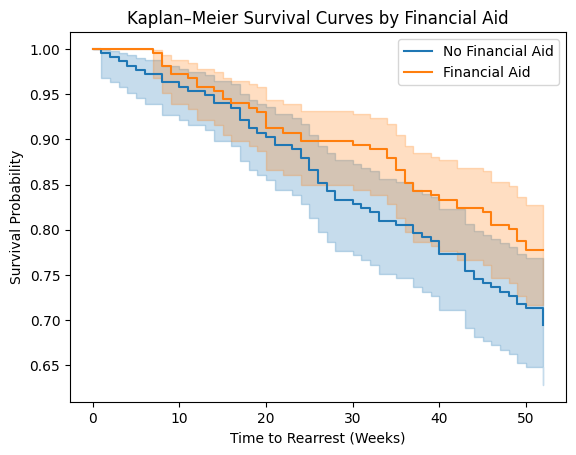

In [17]:
from lifelines import KaplanMeierFitter

kmf_no_aid = KaplanMeierFitter()
kmf_aid = KaplanMeierFitter()

group_no_aid = df[df["fin"] == 0]
group_aid = df[df["fin"] == 1]

ax = kmf_no_aid.fit(
    group_no_aid["T"],
    event_observed=group_no_aid["E"],
    label="No Financial Aid"
).plot_survival_function()

kmf_aid.fit(
    group_aid["T"],
    event_observed=group_aid["E"],
    label="Financial Aid"
).plot_survival_function(ax=ax)

plt.xlabel("Time to Rearrest (Weeks)")
plt.ylabel("Survival Probability")
plt.title("Kaplan–Meier Survival Curves by Financial Aid")
plt.show()

### Interpretation

The Kaplan–Meier curve for the financial aid group is generally above the curve for the no-financial-aid group.

This suggests a possible difference in survival between the two groups. However, the confidence intervals overlap substantially, so a statistical test is needed to determine whether the difference is significant.

In [18]:
from lifelines.statistics import logrank_test

results = logrank_test(
    group_no_aid["T"],
    group_aid["T"],
    event_observed_A=group_no_aid["E"],
    event_observed_B=group_aid["E"]
)

results.print_summary()

In [19]:
print("Exact p-value:", results.p_value)

Exact p-value: 0.050116117409005755


### Interpretation

The log-rank test produced a p-value of approximately 0.0501.

At a significance level of 0.05, this result is not statistically significant, so we do not reject the null hypothesis of equal survival distributions between the two financial aid groups.

However, the result is very close to the significance threshold, suggesting that the difference between the groups may be worth investigating further.

## 7. Cox Proportional Hazards Model

### AI Question

**What does a hazard ratio represent in a Cox proportional hazards model, and how should a hazard ratio above or below 1 be interpreted?**

In [20]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()

cph.fit(
    df,
    duration_col="T",
    event_col="E"
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'T'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -658.75
         time fit was run = 2026-09-28 07:34:16 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
fin       -0.38      0.68      0.19           -0.75           -0.00                0.47                1.00
age       -0.06      0.94      0.02           -0.10           -0.01                0.90                0.99
race       0.31      1.37      0.31           -0.29            0.92                0.75                2.50
wexp      -0.15      0.86      0.21           -0.57            0.27                0.57                1.30
mar       -0.43      0.65      0.38           -1.18            0.31                0.31                1.37
paro      -0.08      0.92      0.20           -0.47            0.30                0.63                1.35
prio       0.09      1.10      0.03            0.04            0.15                1.04                1.16

           cmp to     z      p  -log2(p)
covariate                               
fin          0.00 -1.98   0.05      4.40
age          0.00 -2.61   0.01      6.79
race         0.00  1.02   0.31      1.70
wexp         0.00 -0.71   0.48      1.06
mar          0.00 -1.14   0.26      1.97
paro         0.00 -0.43   0.66      0.59
prio         0.00  3.19 <0.005      9.48
---
Concordance = 0.64
Partial AIC = 1331.50
log-likelihood ratio test = 33.27 on 7 df
-log2(p) of ll-ratio test = 15.37

### Interpretation

The Cox model shows that age and prior history (`prio`) are important predictors of the hazard of rearrest.

- The hazard ratio for `age` is 0.94, suggesting that the hazard of rearrest decreases as age increases.
- The hazard ratio for `prio` is 1.10, suggesting that the hazard of rearrest increases as `prio` increases.
- The effect of financial aid (`fin`) appears borderline, with a hazard ratio below 1 and a p-value close to 0.05.
- The remaining covariates do not show statistically significant effects at the 0.05 level.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'age' failed the non-proportional test: p-value is 0.0007.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


2. Variable 'wexp' failed the non-proportional test: p-value is 0.0063.

   Advice: with so few unique values (only 2), you can include `strata=['wexp', ...]` in the call in
`.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a mome

[[<Axes: xlabel='rank-transformed time\n(p=0.9023)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8900)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0007)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0009)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2323)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2306)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0068)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0063)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3996)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4382)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7140)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7337)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8908)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8806)'>]]

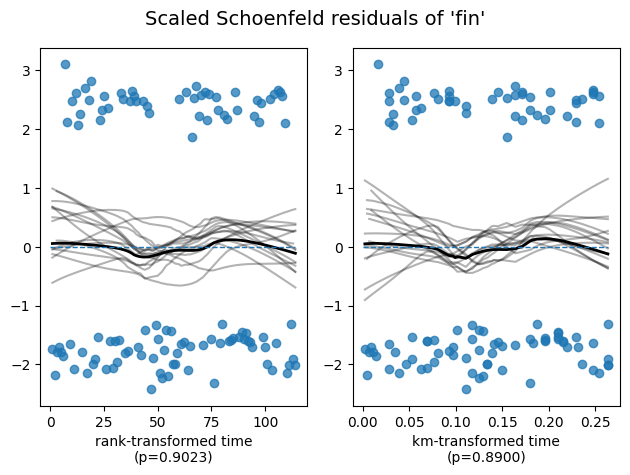

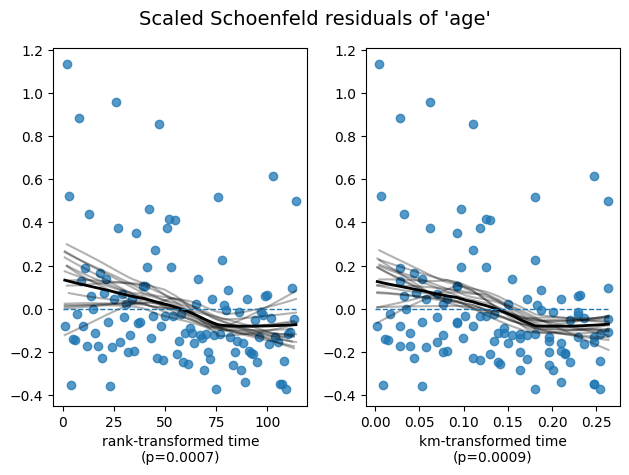

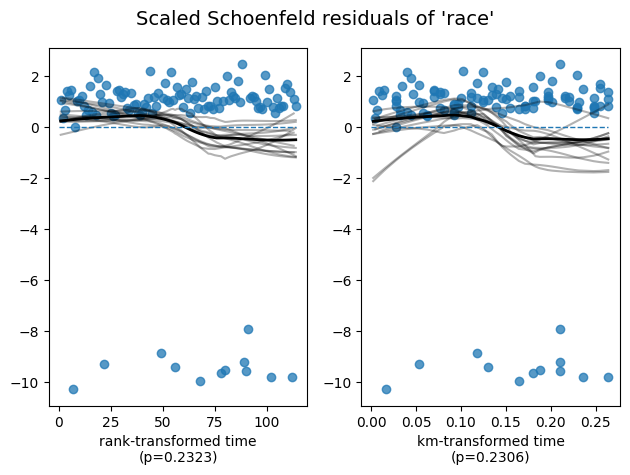

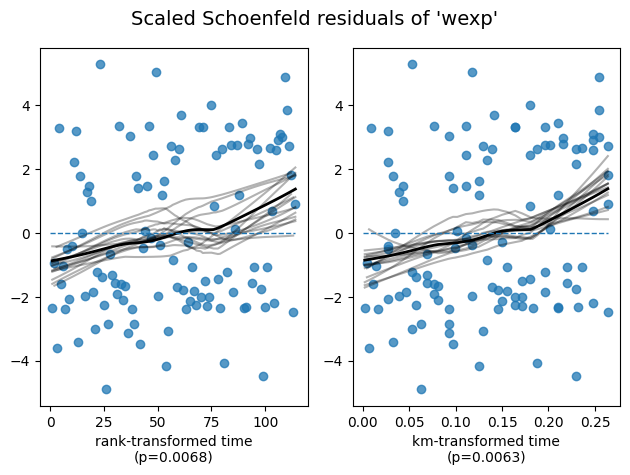

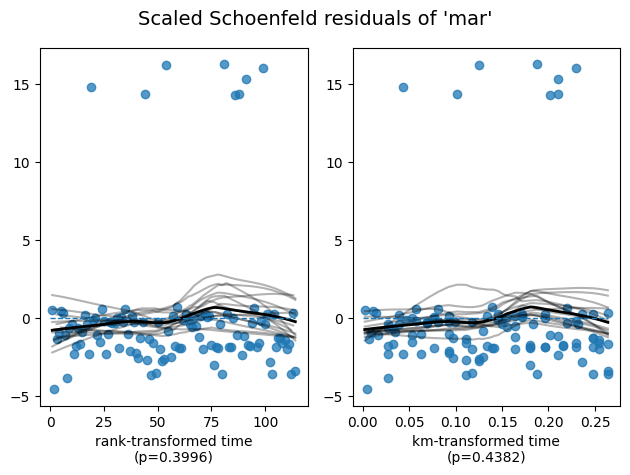

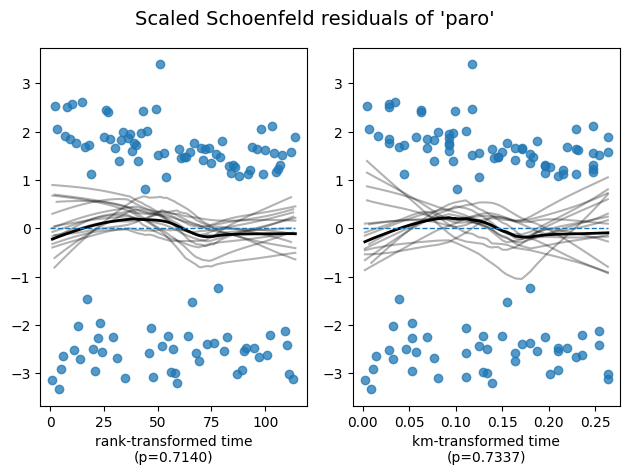

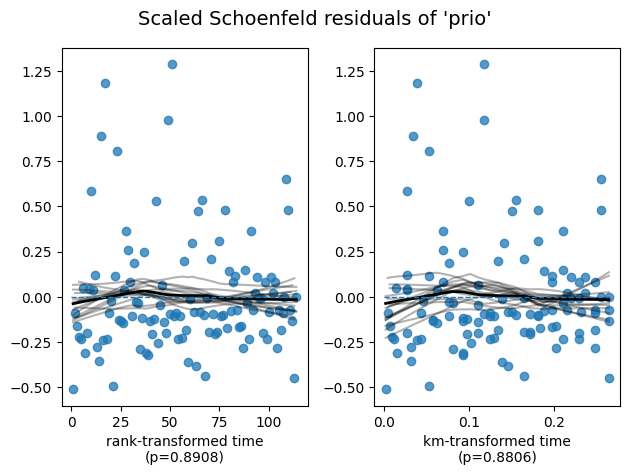

In [21]:
cph.check_assumptions(df, show_plots=True)

### Cox Model with Stratification by Work Experience

In [22]:
cph_stratified = CoxPHFitter()

cph_stratified.fit(
    df,
    duration_col="T",
    event_col="E",
    strata=["wexp"]
)

cph_stratified.print_summary()

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'T'
                event col = 'E'
                   strata = wexp
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -580.89
         time fit was run = 2026-09-28 07:40:01 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
fin       -0.38      0.68      0.19           -0.76           -0.01                0.47                0.99
age       -0.06      0.94      0.02           -0.10           -0.01                0.90                0.99
race       0.31      1.36      0.31           -0.30            0.91                0.74                2.49
mar       -0.45      0.64      0.38           -1.20            0.29                0.30                1.34
paro      -0.08      0.92      0.20           -0.47            0.30                0.63                1.35
prio       0.09      1.09      0.03            0.03            0.15                1.04                1.16

           cmp to     z      p  -log2(p)
covariate                               
fin          0.00 -1.99   0.05      4.42
age          0.00 -2.64   0.01      6.91
race         0.00  1.00   0.32      1.65
mar          0.00 -1.19   0.23      2.09
paro         0.00 -0.42   0.67      0.57
prio         0.00  3.16 <0.005      9.33
---
Concordance = 0.61
Partial AIC = 1173.77
log-likelihood ratio test = 23.77 on 6 df
-log2(p) of ll-ratio test = 10.77

### Interpretation

After stratifying by work experience (`wexp`), the model allows the baseline hazard to differ between the two work-experience groups.

The estimated effects of the remaining covariates are similar to those in the original Cox model. Age is associated with a lower hazard of rearrest, while prior history (`prio`) is associated with a higher hazard.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'age' failed the non-proportional test: p-value is 0.0008.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/

[[<Axes: xlabel='rank-transformed time\n(p=0.8251)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8970)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0315)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0008)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4249)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2258)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2520)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4677)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9676)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7587)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8977)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8933)'>]]

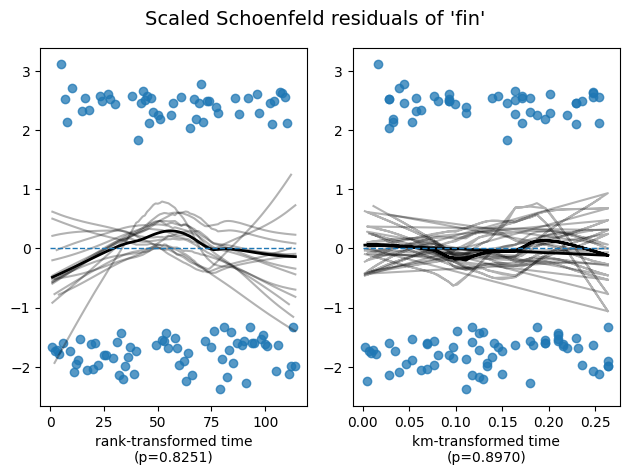

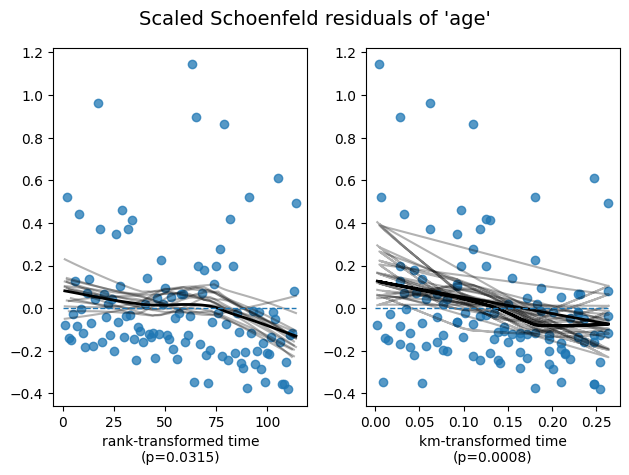

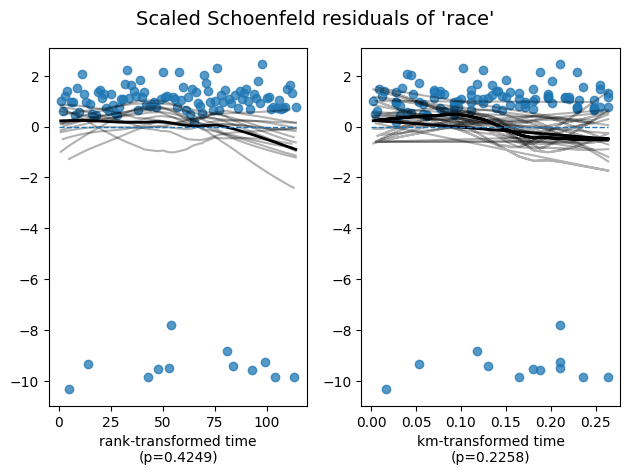

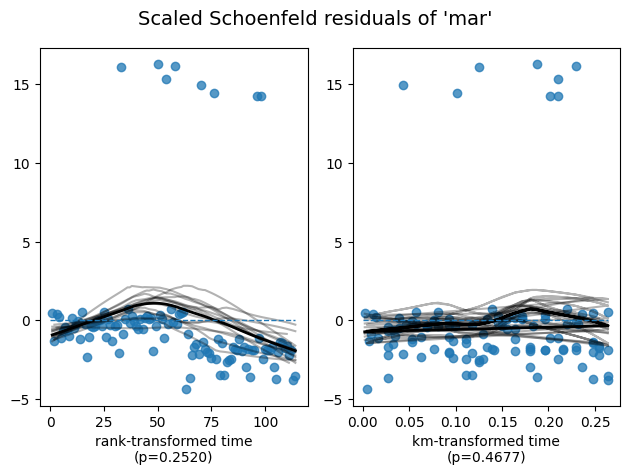

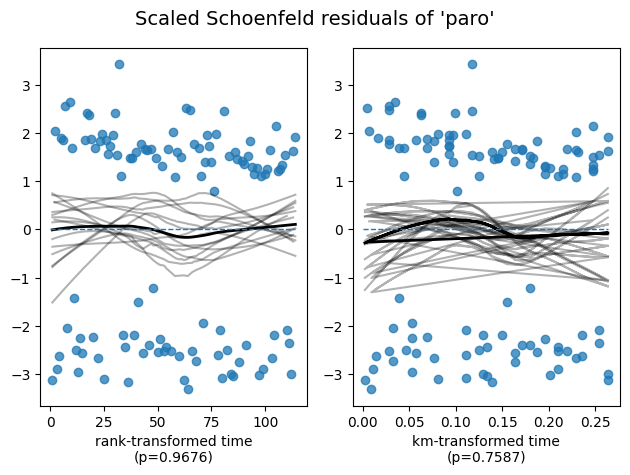

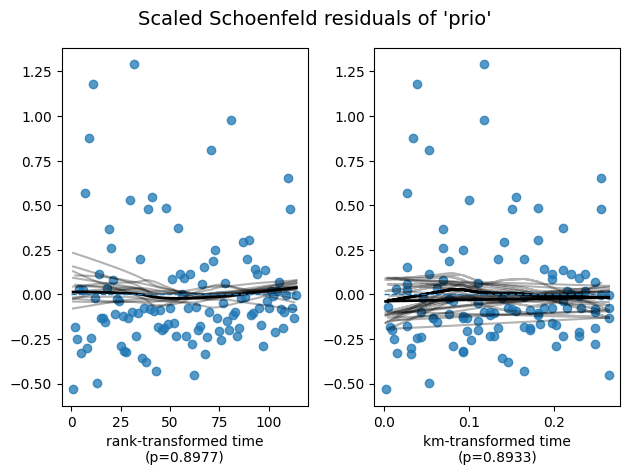

In [23]:
cph_stratified.check_assumptions(df, show_plots=True)

### Interpretation

After stratifying by `wexp`, work experience is no longer treated as a covariate with a proportional effect over time.

However, the Schoenfeld residuals still suggest that the proportional hazards assumption may be violated for `age`.

Therefore, the estimated effect of age should be interpreted with caution, while the proportional hazards assumption appears more reasonable for the remaining covariates.

### Predicted Survival by Financial Aid

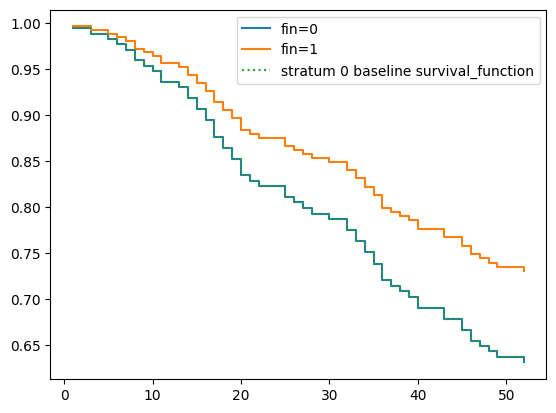

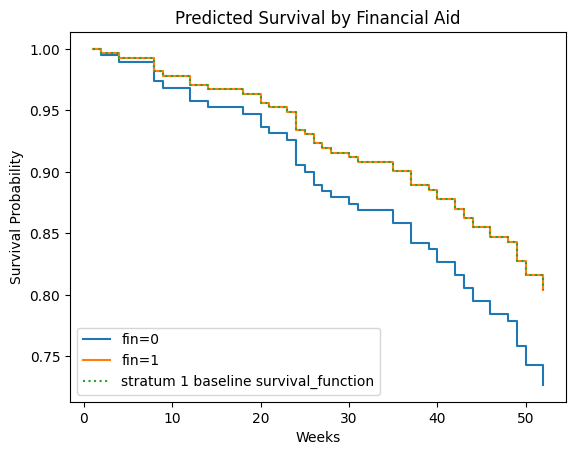

In [24]:
cph_stratified.plot_partial_effects_on_outcome(
    covariates="fin",
    values=[0, 1]
)

plt.title("Predicted Survival by Financial Aid")
plt.xlabel("Weeks")
plt.ylabel("Survival Probability")
plt.show()

### Interpretation

In both work-experience strata, the predicted survival curve for individuals receiving financial aid (`fin = 1`) is above the curve for individuals not receiving financial aid (`fin = 0`).

This is consistent with the Cox model hazard ratio below 1 for `fin`, suggesting a lower hazard of rearrest among individuals receiving financial aid.

However, since the statistical evidence for `fin` is borderline, this relationship should be interpreted cautiously.

## Conclusion

This analysis demonstrated several approaches to survival analysis using the Rossi recidivism dataset.

- Right-censored observations contain important information and should not simply be excluded from survival analysis.
- Parametric models such as the exponential and Weibull distributions provide different descriptions of survival times, and accounting for censoring can substantially affect model estimates.
- The Kaplan–Meier estimator provides a more appropriate estimate of survival than an empirical survival curve that ignores censoring.
- The financial aid group showed generally higher survival probabilities, although the log-rank test result was just above the 0.05 significance level.
- In the Cox proportional hazards model, age and prior history were important predictors of rearrest. Diagnostic testing also showed that the proportional hazards assumption requires caution, particularly for age.